# OCPM analysis
In this notebook, we analyse the generated OCELs using OCPM and our novel split-tree-mining approach

In [20]:
import pm4py
import pandas as pd
import os, json
from collections import defaultdict

In [21]:
class Split_tree:
    def __init__(self,root):
        self.root = root
        self.nodes = [root]
        self.leaves = []
        self.splits = 0
    
    

## Combine traces to coherent OCEL

In [22]:
complete_ocel_json = {}
complete_ocel_json["objects"] = []
complete_ocel_json["events"] =[]
o_count = 0
path = "../Output/"
json_files = [pos_json for pos_json in os.listdir(path) if pos_json.endswith('.json')]
with open(os.path.join(path,json_files[0])) as init_js:
    json_text = json.load(init_js)
    complete_ocel_json["objectTypes"]= json_text["objectTypes"]
    complete_ocel_json["eventTypes"]= json_text["eventTypes"]

for index, js in enumerate(json_files):
    with open(os.path.join(path, js)) as json_file:
        json_ocel = json.load(json_file)
        o_count += len(json_ocel["objects"])
        complete_ocel_json["objects"] +=(json_ocel["objects"])
        complete_ocel_json["events"]+=(json_ocel["events"])

# Serializing json
json_object = json.dumps(complete_ocel_json)

# Writing to sample.json
with open("OCEL.json", "w") as outfile:
    outfile.write(json_object)

In [23]:
ocel = pm4py.read_ocel2_json("OCEL.json")

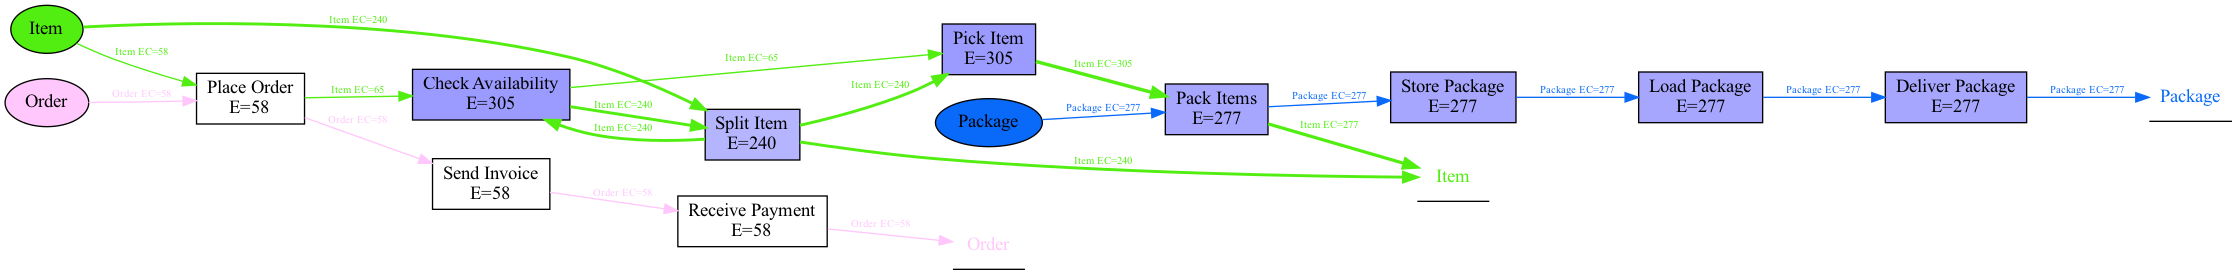

In [5]:
pm4py.view_ocdfg(pm4py.discover_ocdfg(ocel))

## Mine Split trees

1. initialize all items as not visited
2. find all roots via order placed
2. initialise graph for each root
3. get list of all split events
4. iterate over splits, marking item as visited and adding them to queue while adding edges


In [24]:
items = ocel.objects[ocel.objects['ocel:type']=="Item"]["ocel:oid"].unique()
order_placed = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Place Order'])

nested_roots = order_placed.get_extended_table()["ocel:type:Item"].tolist()
roots = []
for nested_root in nested_roots:
    for root in nested_root:
        roots.append(root)

split_df = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()
split_parents = ocel.relations[(ocel.relations["ocel:activity"]=="Split Item") & (ocel.relations["ocel:qualifier"]=="Split of available items for delivery")]
split_trees={}

for root in roots:
    split_trees[root]=(Split_tree(root))

In [27]:
len(roots)

62

In [10]:
for root in roots:
    queue = [root]
    if root == "item_6_1":
        print("here")
    while queue:
        current = queue.pop(0)
        if current in split_parents["ocel:oid"].copy().to_numpy():
            split_id = split_parents[split_parents["ocel:oid"]==current]["ocel:eid"].to_numpy()[0]
            split = split_df[split_df["ocel:eid"]==split_id]["ocel:type:Item"].to_numpy()[0]
            split.remove(current)
            split_trees[root].nodes += split
            queue += split
            split_trees[root].splits += 1
        else:
            split_trees[root].leaves.append(current)


In [11]:
for root in split_trees.keys():
    if split_trees[root].splits > 5:
        print(root)

item_20_1
item_34_0
item_49_0


In [28]:
ocel.get_extended_table().shape

(2089, 15)

In [12]:
split_trees['item_20_1'].leaves

['item_20_1_2956',
 'item_20_1_1024',
 'item_20_1_7584',
 'item_20_1_7357',
 'item_20_1_2978',
 'item_20_1_1795',
 'item_20_1_2271']

In [13]:
ocel.relations[ocel.relations["ocel:eid"]=="e_1_0_5_company_1_0"]

,ocel:eid,ocel:activity,ocel:timestamp,ocel:oid,ocel:type,ocel:qualifier


In [19]:
pm4py.filter_ocel_objects(ocel,'item_5_1')

Object-Centric Event Log (number of events: 0, number of objects: 0, number of activities: 0, number of object types: 0, events-objects relationships: 0)
Activities occurrences: Counter()
Object types occurrences (number of objects): Counter()
Unique activities per object type: Counter()
Please use <THIS>.get_extended_table() to get a dataframe representation of the events related to the objects.

In [14]:
pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,ocel:type:Item
0,e_0_0_5_company_1_0,2025-05-27 08:57:38+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_0_0_2394, item_0_0_2350, item_0_0]"
1,e_0_1_5_company_1_0,2025-05-29 08:35:38+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,"[item_0_0_9176, item_0_0_6251, item_0_0_2350]"
2,e_1_0_5_company_1_1,2025-06-03 09:00:38+00:00,Split Item,NaN,NaN,NaN,D. Brown,NaN,NaN,NaN,NaN,NaN,"[item_1_1_5050, item_1_1, item_1_1_8856]"
3,e_0_2_5_company_1_0,2025-06-04 16:48:38+00:00,Split Item,NaN,NaN,NaN,D. Brown,NaN,NaN,NaN,NaN,NaN,"[item_0_0_9176, item_0_0_8548, item_0_0_9577]"
4,e_1_1_5_company_1_1,2025-06-08 08:18:38+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_1_1_5050, item_1_1_2265, item_1_1_1385]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,e_58_4_5_company_1_0,2028-01-28 08:46:38+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,"[item_58_0_1673, item_58_0_2588, item_58_0_1687]"
236,e_59_0_5_company_1_1,2028-02-03 09:00:38+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_59_1_8250, item_59_1_3561, item_59_1]"
237,e_59_1_5_company_1_1,2028-02-06 08:33:38+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_59_1_5368, item_59_1_8250, item_59_1_4381]"
238,e_59_2_5_company_1_1,2028-02-12 09:00:38+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,"[item_59_1_1329, item_59_1_4381, item_59_1_6291]"


## Analyse Processes
1. order completion
2. mean item lead time

metadata: #num objects, num events, events time?